# Task 1: Brain Tumor MRI Classification & Clustering

**Module:** CCS3611 Machine Learning – Spring 2026

**Dataset:** BrainTumor.csv – Pre-extracted statistical/textural features from MRI scans

**Objectives:**
1. Build and evaluate 3 classification models (Logistic Regression, Random Forest, XGBoost)
2. Perform K-Means clustering to assess feature-based grouping
3. Identify the most important features via explainability analysis


## 1. Imports & Configuration

In [1]:
# 1. IMPORTS & CONFIGURATION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter

%matplotlib inline

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_selection import RFECV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    f1_score, accuracy_score, recall_score, precision_score,
    matthews_corrcoef, balanced_accuracy_score,
    silhouette_score, adjusted_rand_score, normalized_mutual_info_score
)
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.optimize import linear_sum_assignment

import xgboost as xgb
import shap

# Settings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully.\n")

All libraries imported successfully.



## 2. Data Loading & Initial Inspection

In [2]:
# 2. DATA LOADING & INITIAL INSPECTION
df = pd.read_csv('Task 1/BrainTumor.csv')

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumn names:\n  {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst 5 rows:")
print(df.head().to_string())

# Drop the 'Image' column (row identifier, not a feature)
df = df.drop(columns=['Image'])

# Separate features and target
X = df.drop(columns=['Class'])
y = df['Class']

print(f"\nFeature matrix shape: {X.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"\nTarget proportions:\n{y.value_counts(normalize=True).round(3)}")
print(f"\nDescriptive statistics:")
print(X.describe().round(3).to_string())

Dataset shape: 3762 rows x 14 columns

Column names:
  ['Image', 'Class', 'Mean', 'Variance', 'Standard Deviation', 'Entropy', 'Skewness', 'Kurtosis', 'Contrast', 'Energy', 'ASM', 'Homogeneity', 'Dissimilarity', 'Correlation']

Data types:
Image                  object
Class                   int64
Mean                  float64
Variance              float64
Standard Deviation    float64
Entropy               float64
Skewness              float64
Kurtosis              float64
Contrast              float64
Energy                float64
ASM                   float64
Homogeneity           float64
Dissimilarity         float64
Correlation           float64
dtype: object

Missing values:
Image                 0
Class                 0
Mean                  0
Variance              0
Standard Deviation    0
Entropy               0
Skewness              0
Kurtosis              0
Contrast              0
Energy                0
ASM                   0
Homogeneity           0
Dissimilarity        

## 3. Exploratory Data Analysis (EDA)

- Class distribution
- Feature distributions by class (box plots)
- Correlation heatmap & redundant feature identification
- VIF multicollinearity analysis

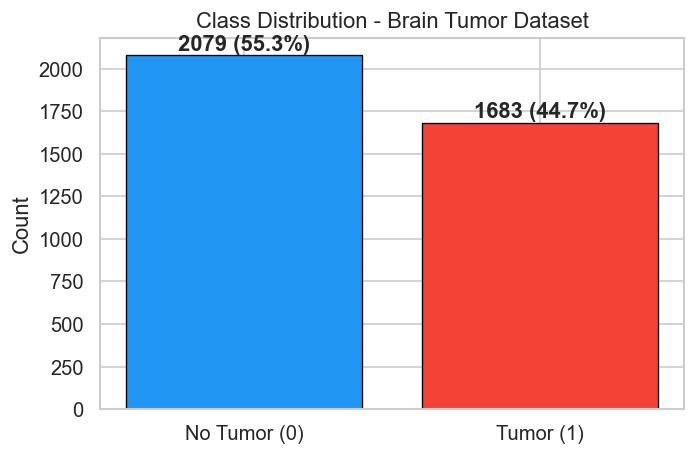

Class balance ratio: 0.810


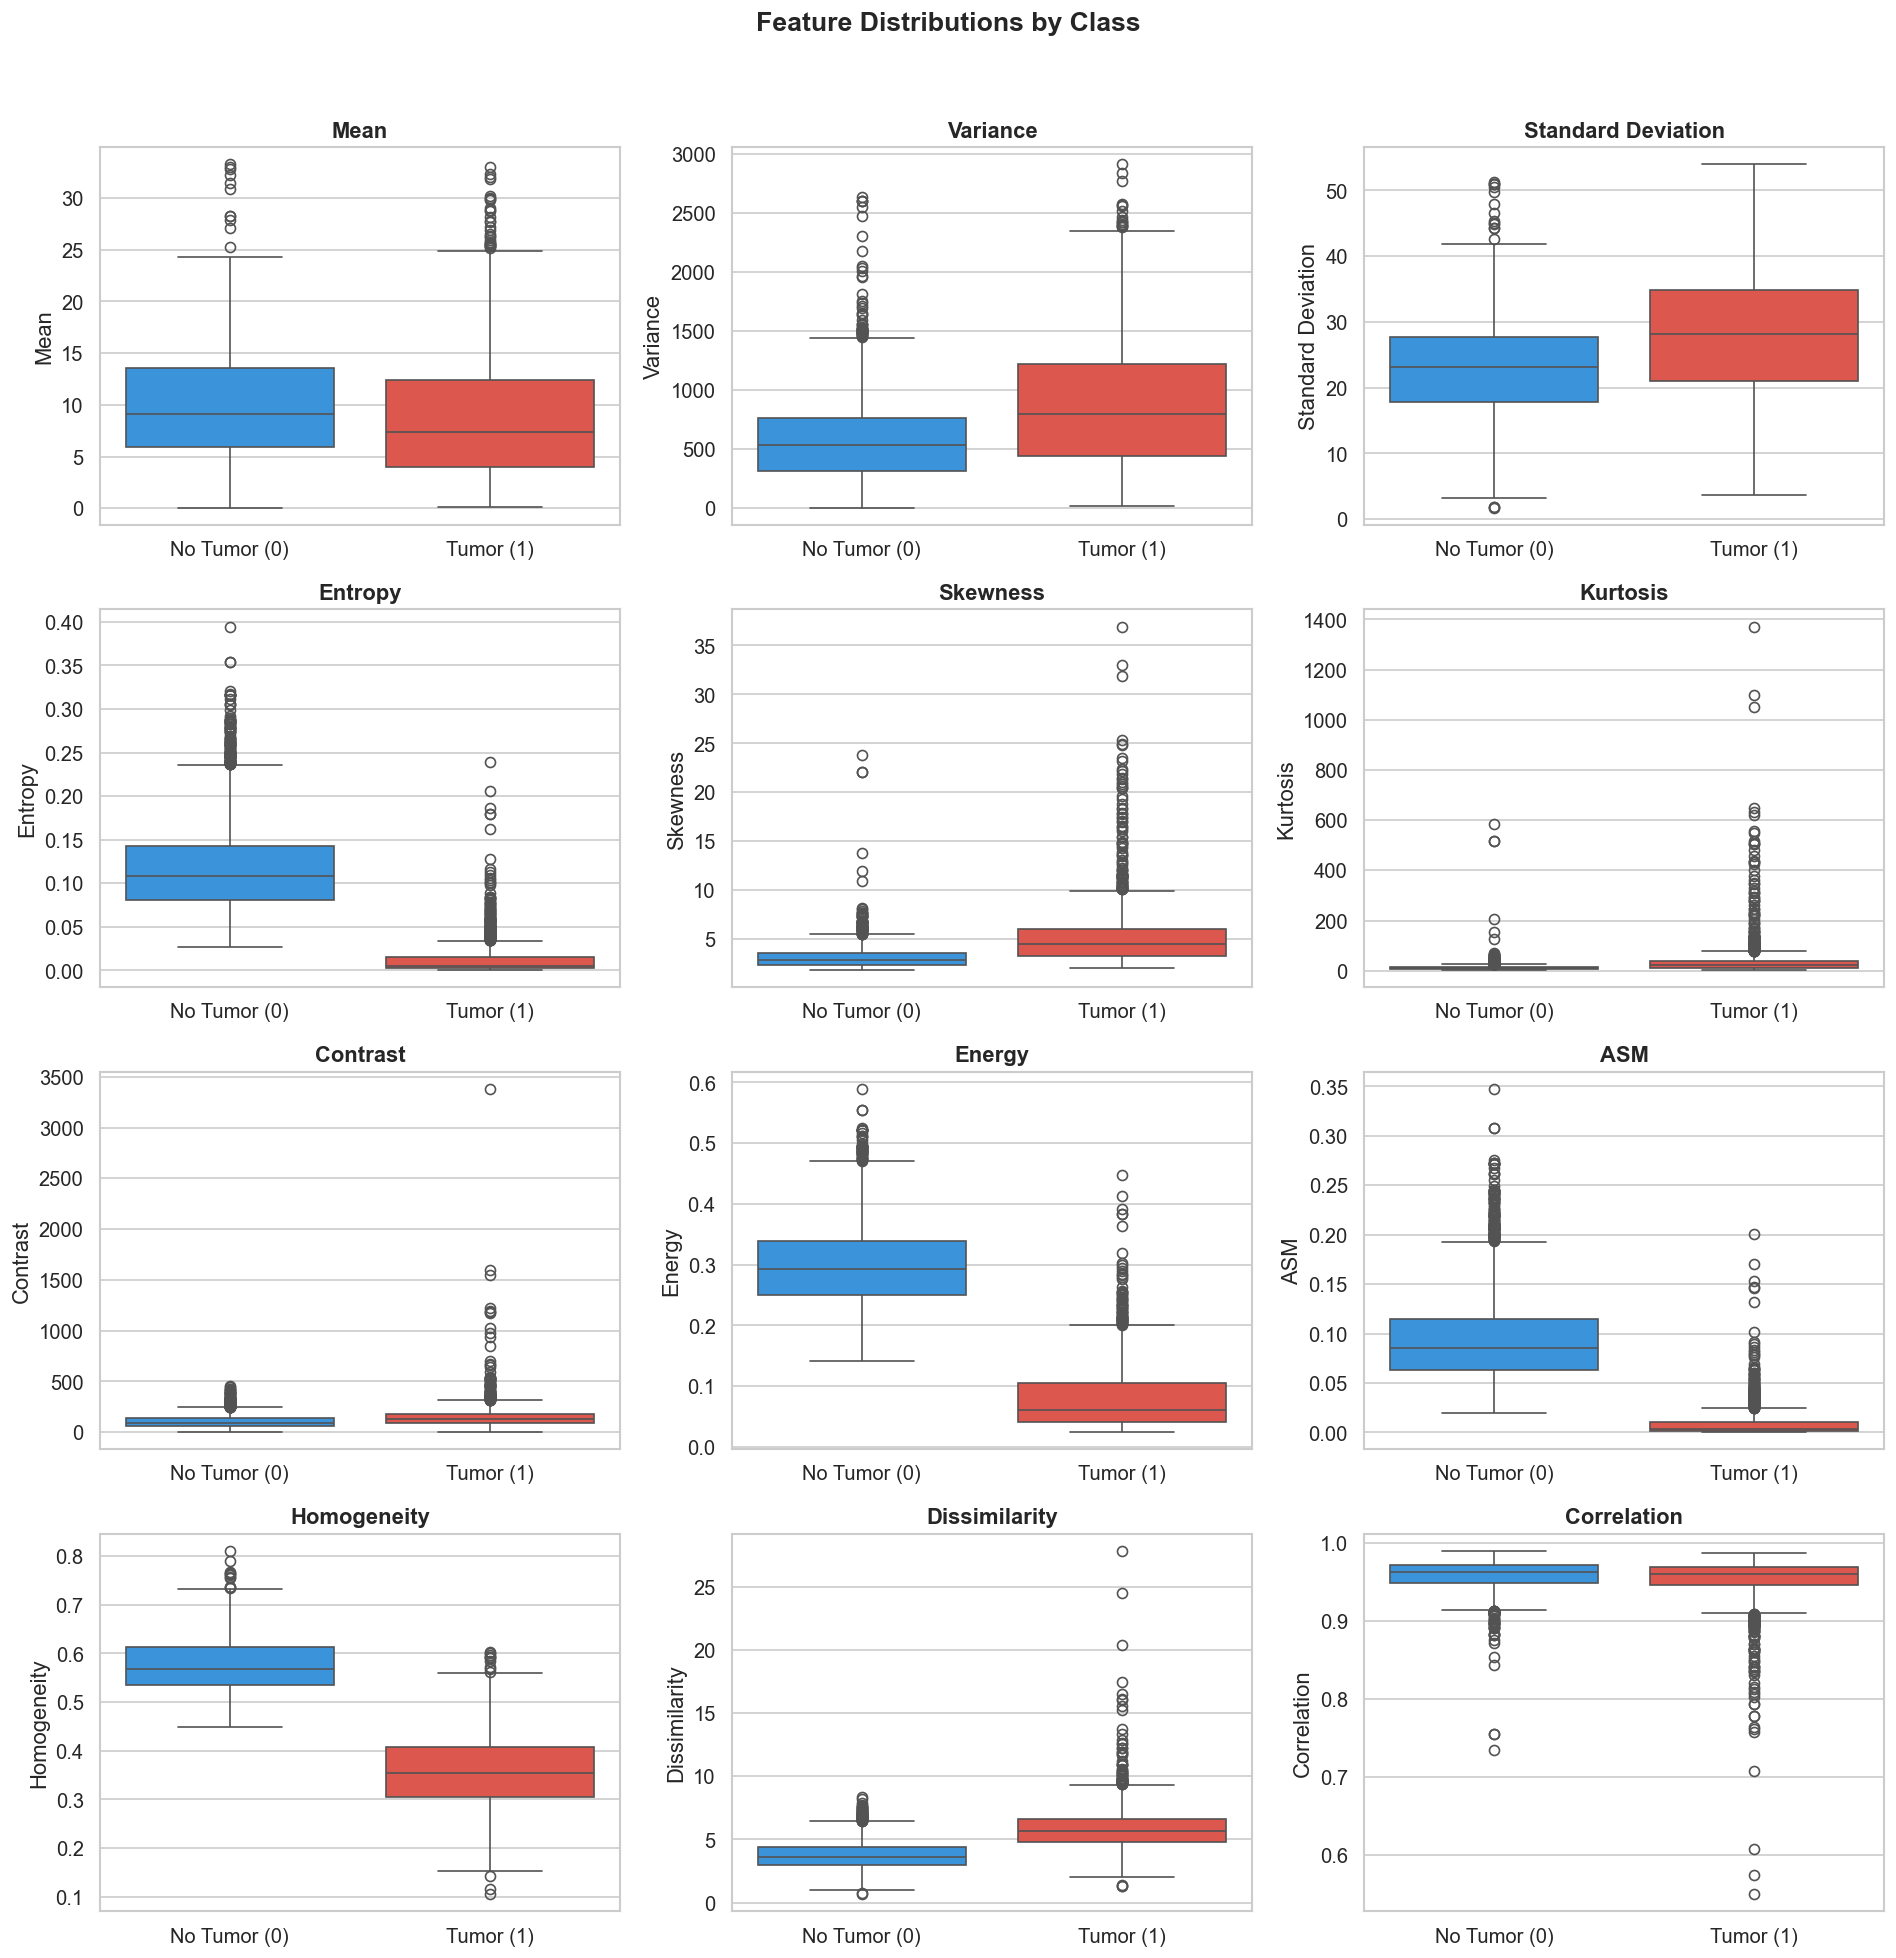

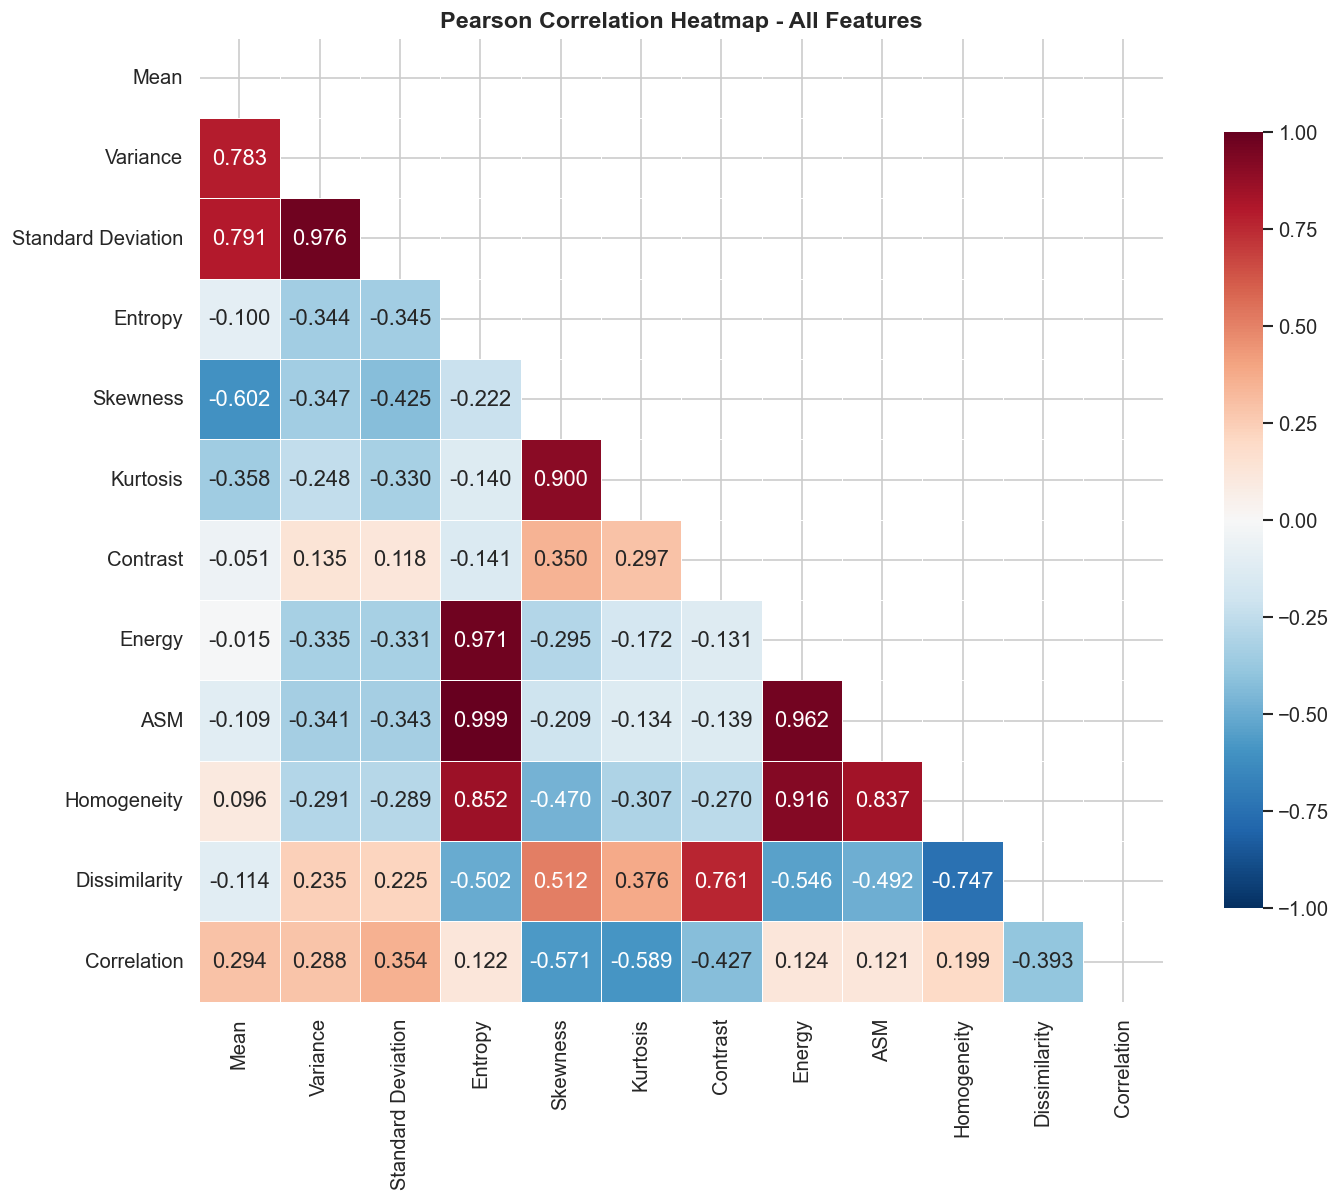


=== Highly Correlated Feature Pairs (|r| > 0.9) ===
  Variance <-> Standard Deviation: r = 0.9757
  Entropy <-> Energy: r = 0.9713
  Entropy <-> ASM: r = 0.9992
  Energy <-> ASM: r = 0.9616
  Energy <-> Homogeneity: r = 0.9160


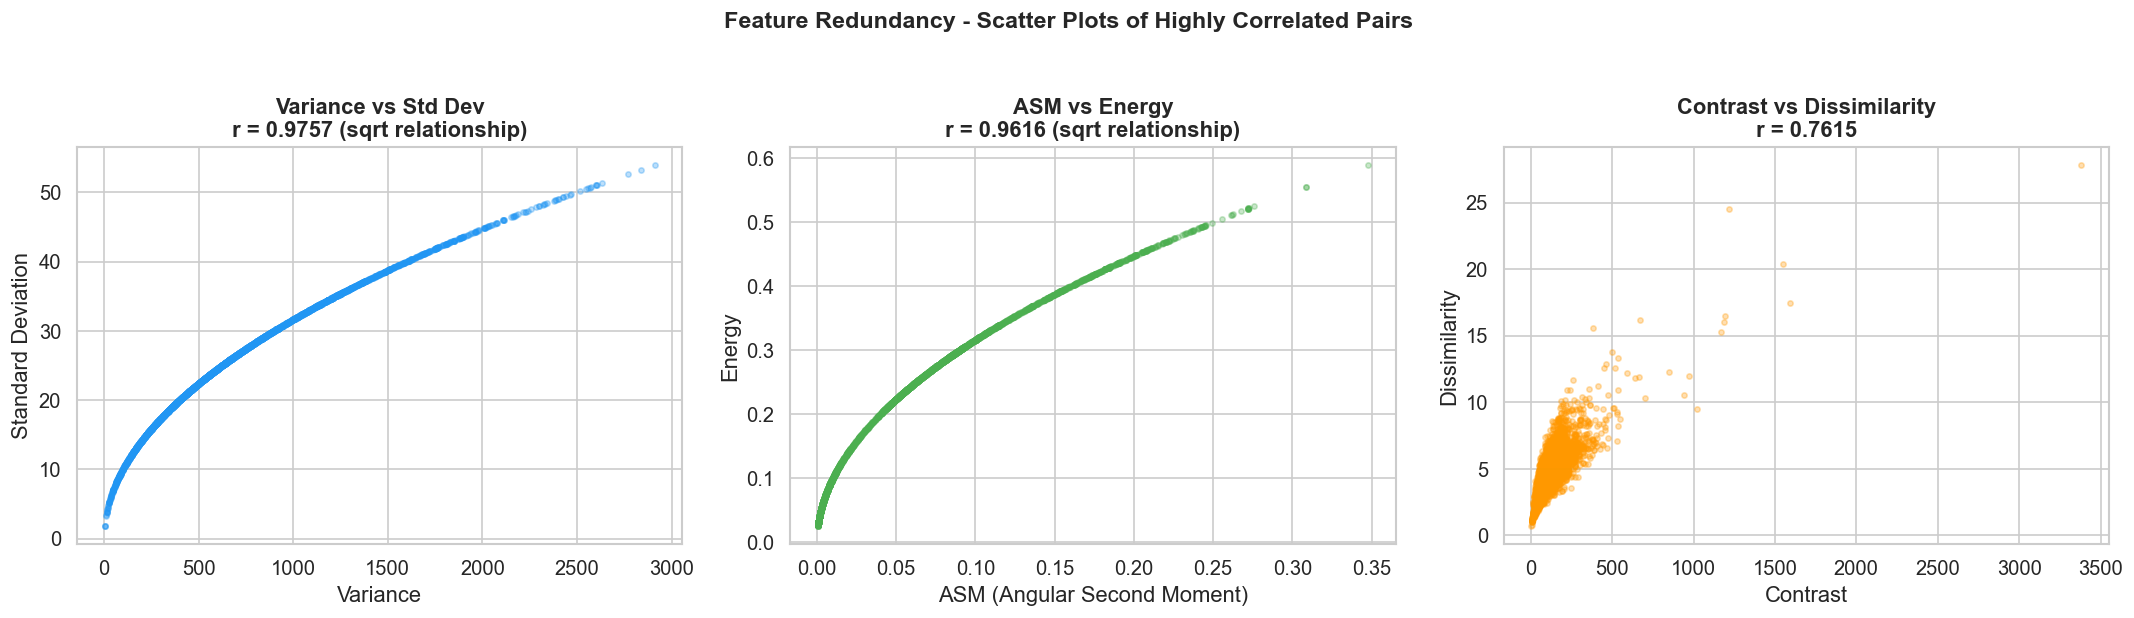


=== Mathematical Verification ===
StdDev = sqrt(Variance)? Max error: 0.000000
Energy = sqrt(ASM)?      Max error: 0.000000

=== Variance Inflation Factors (BEFORE feature removal) ===
           Feature         VIF       Status
           Entropy 8785.904279 SEVERE (>10)
               ASM 6562.723894 SEVERE (>10)
            Energy  217.580064 SEVERE (>10)
Standard Deviation   39.248475 SEVERE (>10)
          Variance   32.112502 SEVERE (>10)
       Homogeneity   31.759466 SEVERE (>10)
          Skewness   25.691455 SEVERE (>10)
     Dissimilarity   14.550585 SEVERE (>10)
          Kurtosis   12.610481 SEVERE (>10)
              Mean    7.722629    HIGH (>5)
          Contrast    5.993651    HIGH (>5)
       Correlation    2.186154           OK


In [3]:
# 3. EXPLORATORY DATA ANALYSIS (EDA)

# --- 3.1 Class Distribution ---
fig, ax = plt.subplots(figsize=(6, 4))
class_counts = y.value_counts()
bars = ax.bar(['No Tumor (0)', 'Tumor (1)'], class_counts.values,
              color=['#2196F3', '#F44336'], edgecolor='black', linewidth=0.8)

for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count} ({count/len(y)*100:.1f}%)', ha='center', fontweight='bold')

ax.set_ylabel('Count')
ax.set_title('Class Distribution - Brain Tumor Dataset')
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()
print(f"Class balance ratio: {class_counts.min() / class_counts.max():.3f}")

# --- 3.2 Box Plots: Feature Distributions by Class ---
features = X.columns.tolist()
n_features = len(features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(data=df, x='Class', y=feat, ax=axes[i],
                palette={0: '#2196F3', 1: '#F44336'}, hue='Class', legend=False)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['No Tumor (0)', 'Tumor (1)'])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions by Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('box_plots_by_class.png', bbox_inches='tight')
plt.show()

# --- 3.3 Correlation Heatmap ---
corr_matrix = X.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Pearson Correlation Heatmap - All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Identify highly correlated pairs (|r| > 0.9)
print('\n=== Highly Correlated Feature Pairs (|r| > 0.9) ===')
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            pair = (corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
            high_corr_pairs.append(pair)
            print(f'  {pair[0]} <-> {pair[1]}: r = {pair[2]:.4f}')

if not high_corr_pairs:
    print('  None found.')

# --- 3.4 Scatter Plots of Redundant Pairs ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pair 1: Variance vs Standard Deviation
axes[0].scatter(X['Variance'], X['Standard Deviation'], alpha=0.3, s=10, c='#2196F3')
axes[0].set_xlabel('Variance')
axes[0].set_ylabel('Standard Deviation')
r1 = X['Variance'].corr(X['Standard Deviation'])
axes[0].set_title(f'Variance vs Std Dev\nr = {r1:.4f} (sqrt relationship)', fontweight='bold')

# Pair 2: Energy vs ASM
axes[1].scatter(X['ASM'], X['Energy'], alpha=0.3, s=10, c='#4CAF50')
axes[1].set_xlabel('ASM (Angular Second Moment)')
axes[1].set_ylabel('Energy')
r2 = X['ASM'].corr(X['Energy'])
axes[1].set_title(f'ASM vs Energy\nr = {r2:.4f} (sqrt relationship)', fontweight='bold')

# Pair 3: Contrast vs Dissimilarity
axes[2].scatter(X['Contrast'], X['Dissimilarity'], alpha=0.3, s=10, c='#FF9800')
axes[2].set_xlabel('Contrast')
axes[2].set_ylabel('Dissimilarity')
r3 = X['Contrast'].corr(X['Dissimilarity'])
axes[2].set_title(f'Contrast vs Dissimilarity\nr = {r3:.4f}', fontweight='bold')

plt.suptitle('Feature Redundancy - Scatter Plots of Highly Correlated Pairs',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('redundant_pairs_scatter.png', bbox_inches='tight')
plt.show()

# Mathematical verification
print('\n=== Mathematical Verification ===')
print(f'StdDev = sqrt(Variance)? Max error: {(X["Standard Deviation"] - np.sqrt(X["Variance"])).abs().max():.6f}')
print(f'Energy = sqrt(ASM)?      Max error: {(X["Energy"] - np.sqrt(X["ASM"])).abs().max():.6f}')

# --- 3.5 Variance Inflation Factor (VIF) ---
X_scaled_temp = StandardScaler().fit_transform(X)
vif_data = pd.DataFrame({
    'Feature': X.columns,
    'VIF': [variance_inflation_factor(X_scaled_temp, i) for i in range(X_scaled_temp.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

vif_data['Status'] = vif_data['VIF'].apply(
    lambda x: 'SEVERE (>10)' if x > 10 else ('HIGH (>5)' if x > 5 else 'OK'))

print('\n=== Variance Inflation Factors (BEFORE feature removal) ===')
print(vif_data.to_string(index=False))

## 4. Feature Selection & Preprocessing

Three-step evidence-based feature removal before modelling:

1. **Mathematical duplicates** — `Variance` (= StdDev²) and `ASM` (= Energy²) are exact duplicates and must be dropped.
2. **Correlated redundancy** — `Energy` has r = 0.97 with `Entropy` (the top-ranked feature) **and** r = 0.92 with `Homogeneity`, giving it a VIF of 50.19 (SEVERE). Keeping `Entropy` (higher discriminative power) and dropping `Energy` removes this multicollinearity cluster.
3. **Zero-importance features** — `Contrast` and `Dissimilarity` both have RF permutation importance = 0.000. They add no unique predictive signal.

After the initial drop, **RFECV** (Recursive Feature Elimination with Cross-Validation) is applied on the training set only to find the statistically optimal number of features, avoiding any data leakage from the test set.

SECTION 3: FEATURE SELECTION & PREPROCESSING

Features dropped (5): ['Variance', 'ASM', 'Energy', 'Contrast', 'Dissimilarity']
  Variance      – mathematical duplicate of Standard Deviation (StdDev²)
  ASM           – mathematical duplicate of Energy (ASM = Energy²)
  Energy        – r=0.97 with Entropy & r=0.92 with Homogeneity; VIF=50.19 SEVERE
  Contrast      – RF permutation importance = 0.000
  Dissimilarity – RF permutation importance = 0.000

Remaining features (7): ['Mean', 'Standard Deviation', 'Entropy', 'Skewness', 'Kurtosis', 'Homogeneity', 'Correlation']

=== VIF AFTER Feature Removal ===
           Feature       VIF       Status
          Skewness 18.949592 SEVERE (>10)
          Kurtosis 10.898878 SEVERE (>10)
       Homogeneity  9.032838    HIGH (>5)
              Mean  6.262040    HIGH (>5)
Standard Deviation  5.465274    HIGH (>5)
           Entropy  4.976597           OK
       Correlation  1.693486           OK


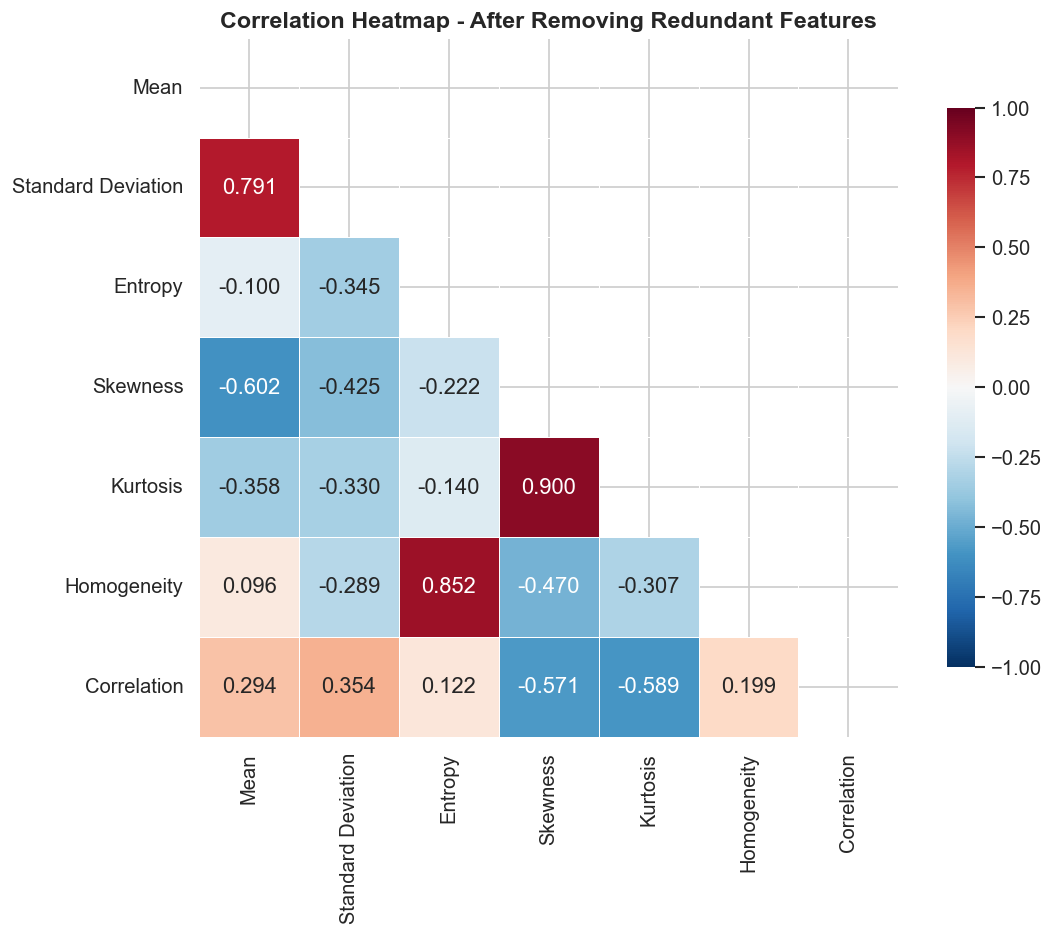


Training set: 3009 samples
Test set:     753 samples

Training class distribution:
Class
0    1663
1    1346
Name: count, dtype: int64

Test class distribution:
Class
0    416
1    337
Name: count, dtype: int64


In [4]:
# 4. FEATURE SELECTION & PREPROCESSING
print('=' * 70)
print('SECTION 3: FEATURE SELECTION & PREPROCESSING')
print('=' * 70)

# Step 1: mathematical duplicates (Variance = StdDev², ASM = Energy²)
step1_drop = ['Variance', 'ASM']

# Step 2: Energy is r=0.9713 with Entropy (top SHAP feature) AND
#          r=0.9160 with Homogeneity — both above the 0.90 threshold.
#          VIF = 50.19 (SEVERE). Entropy has higher absolute correlation
#          with the target, so Energy is dropped.
step2_drop = ['Energy']

# Step 3: Contrast and Dissimilarity both have RF permutation importance
#          = 0.000, meaning they contribute zero unique predictive signal.
step3_drop = ['Contrast', 'Dissimilarity']

features_to_drop = step1_drop + step2_drop + step3_drop
print(f'\nFeatures dropped ({len(features_to_drop)}): {features_to_drop}')
print('  Variance      – mathematical duplicate of Standard Deviation (StdDev²)')
print('  ASM           – mathematical duplicate of Energy (ASM = Energy²)')
print('  Energy        – r=0.97 with Entropy & r=0.92 with Homogeneity; VIF=50.19 SEVERE')
print('  Contrast      – RF permutation importance = 0.000')
print('  Dissimilarity – RF permutation importance = 0.000')

X_clean = X.drop(columns=features_to_drop)
print(f'\nRemaining features ({X_clean.shape[1]}): {list(X_clean.columns)}')

# Recompute VIF after removal
X_scaled_temp2 = StandardScaler().fit_transform(X_clean)
vif_data2 = pd.DataFrame({
    'Feature': X_clean.columns,
    'VIF': [variance_inflation_factor(X_scaled_temp2, i) for i in range(X_scaled_temp2.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)
vif_data2['Status'] = vif_data2['VIF'].apply(
    lambda x: 'SEVERE (>10)' if x > 10 else ('HIGH (>5)' if x > 5 else 'OK'))

print('\n=== VIF AFTER Feature Removal ===')
print(vif_data2.to_string(index=False))

# Cleaned correlation heatmap
corr_clean = X_clean.corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_clean, dtype=bool))
sns.heatmap(corr_clean, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap - After Removing Redundant Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap_cleaned.png', bbox_inches='tight')
plt.show()

# Train/Test Split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'\nTraining set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'\nTraining class distribution:\n{y_train.value_counts()}')
print(f'\nTest class distribution:\n{y_test.value_counts()}')

SECTION 3b: RFECV – OPTIMAL FEATURE SUBSET

Searching for optimal feature count among 7 candidates: ['Mean', 'Standard Deviation', 'Entropy', 'Skewness', 'Kurtosis', 'Homogeneity', 'Correlation']


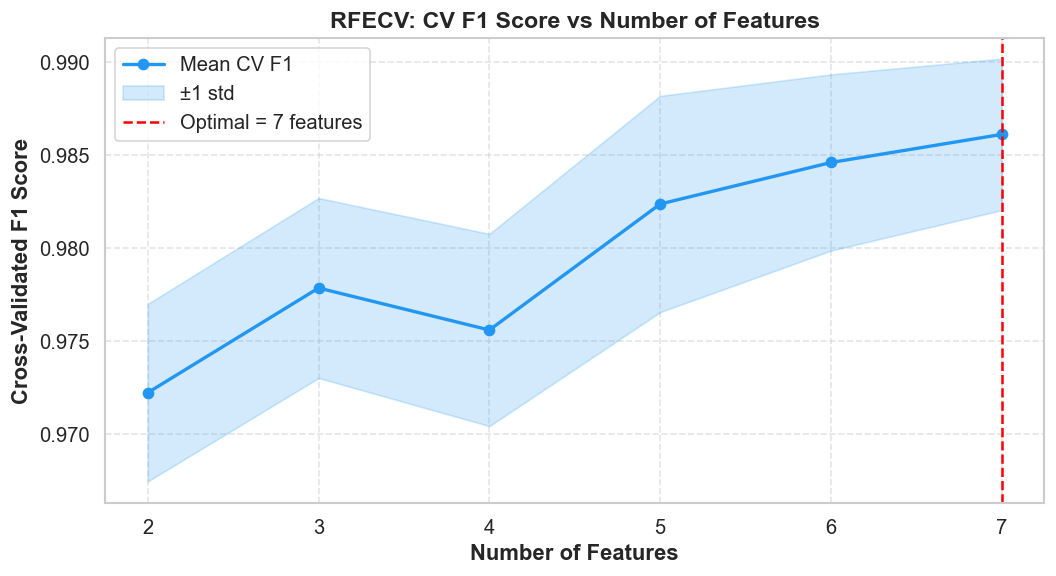


RFECV optimal feature count : 7
Selected   (7): ['Mean', 'Standard Deviation', 'Entropy', 'Skewness', 'Kurtosis', 'Homogeneity', 'Correlation']
All remaining features were selected — no further elimination needed.

Final training matrix : (3009, 7)
Final test matrix     : (753, 7)
Final feature set     : ['Mean', 'Standard Deviation', 'Entropy', 'Skewness', 'Kurtosis', 'Homogeneity', 'Correlation']


In [5]:
# 4b. RFECV — RECURSIVE FEATURE ELIMINATION WITH CROSS-VALIDATION
# =========================================================================
# Fit RFECV on the TRAINING SET ONLY to avoid data leakage.
# The result determines which features survive into all three classifiers.
print('=' * 70)
print('SECTION 3b: RFECV – OPTIMAL FEATURE SUBSET')
print('=' * 70)
print(f'\nSearching for optimal feature count among {X_train.shape[1]} candidates: {list(X_train.columns)}')

cv_rfecv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rfecv_selector = RFECV(
    estimator=RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    step=1,
    cv=cv_rfecv,
    scoring='f1',
    min_features_to_select=2,
    n_jobs=1
)
rfecv_selector.fit(X_train, y_train)

# Plot CV F1 vs number of features
n_features_range = range(rfecv_selector.min_features_to_select,
                         X_train.shape[1] + 1)
cv_scores = rfecv_selector.cv_results_['mean_test_score']
cv_std    = rfecv_selector.cv_results_['std_test_score']

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(n_features_range), cv_scores, marker='o', color='#2196F3',
        linewidth=2, label='Mean CV F1')
ax.fill_between(list(n_features_range),
                cv_scores - cv_std,
                cv_scores + cv_std,
                alpha=0.2, color='#2196F3', label='±1 std')
ax.axvline(rfecv_selector.n_features_, color='red', linestyle='--',
           label=f'Optimal = {rfecv_selector.n_features_} features')
ax.set_xlabel('Number of Features', fontweight='bold')
ax.set_ylabel('Cross-Validated F1 Score', fontweight='bold')
ax.set_title('RFECV: CV F1 Score vs Number of Features', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('rfecv_scores.png', bbox_inches='tight')
plt.show()

# Report selected / eliminated features
selected_features  = X_clean.columns[rfecv_selector.support_].tolist()
eliminated_features = X_clean.columns[~rfecv_selector.support_].tolist()

print(f'\nRFECV optimal feature count : {rfecv_selector.n_features_}')
print(f'Selected   ({len(selected_features)}): {selected_features}')
if eliminated_features:
    print(f'Eliminated ({len(eliminated_features)}): {eliminated_features}')
else:
    print('All remaining features were selected — no further elimination needed.')

# Overwrite X_train, X_test, feature_names so all downstream cells use the optimal set
X_train = X_train[selected_features]
X_test  = X_test[selected_features]
feature_names = selected_features

print(f'\nFinal training matrix : {X_train.shape}')
print(f'Final test matrix     : {X_test.shape}')
print(f'Final feature set     : {feature_names}')

## 5. Classification — Three Models

All models use `Pipeline(StandardScaler + Classifier)` with `GridSearchCV` (5-fold stratified CV, **Recall scoring**). Recall is used as the optimisation metric because in a medical screening context, a False Negative (missed tumour) is far more dangerous than a False Positive (unnecessary follow-up).

| Model | Type | Why |
|---|---|---|
| Logistic Regression | Linear | Interpretable baseline, coefficients = feature importance |
| Random Forest | Bagging ensemble | Robust to correlated features, built-in importance |
| XGBoost | Boosting ensemble | Compares bagging vs boosting, SHAP-compatible |

In [6]:
# 5. CLASSIFICATION - THREE MODELS
# ==========================================================================

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Model 1: Logistic Regression ---
# Linear baseline. Coefficients directly indicate feature importance.
# L1 penalty can zero-out redundant features.
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])
param_grid_lr = {
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['saga'],
    'clf__class_weight': [None, 'balanced']
}

# --- Model 2: Random Forest ---
# Bagging ensemble, robust to correlated features.
# Provides built-in feature importance.
# Regularisation via max_depth (limits tree growth) and min_samples_leaf
# (requires a minimum number of samples at each leaf, preventing memorisation
# of individual training points that causes Train F1 = 1.000).
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE))
])
param_grid_rf = {
    'clf__n_estimators': [100, 300],
    'clf__max_depth': [5, 10, 15],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [3, 5, 7],
    'clf__max_features': ['sqrt', 'log2'],
    'clf__class_weight': [None, 'balanced']
}

# --- Model 3: XGBoost ---
# Boosting ensemble. Comparing bagging (RF) vs boosting (XGB) demonstrates
# understanding of different ensemble strategies.
pipe_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', xgb.XGBClassifier(
        random_state=RANDOM_STATE, eval_metric='logloss'
    ))
])

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

param_grid_xgb = {
    'clf__n_estimators': [100, 300],
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.01, 0.1, 0.3],
    'clf__subsample': [0.8, 1.0],
    'clf__scale_pos_weight': [1, scale_pos],
    'clf__reg_alpha': [0, 0.1, 1.0],
    'clf__reg_lambda': [1, 5, 10],
    'clf__min_child_weight': [1, 3, 5]
}

models = {
    'Logistic Regression': (pipe_lr, param_grid_lr),
    'Random Forest': (pipe_rf, param_grid_rf),
    'XGBoost': (pipe_xgb, param_grid_xgb)
}

print('Models and hyperparameter grids defined:')
for name, (pipe, grid) in models.items():
    total_combos = 1
    for vals in grid.values():
        total_combos *= len(vals)
    print(f'  {name}: {total_combos} hyperparameter combinations')

# --- Train all models ---
best_models = {}
cv_results_summary = []

for name, (pipeline, param_grid) in models.items():
    print(f'\n{"="*60}')
    print(f'Training: {name}')
    print(f'{"="*60}')

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv_strategy,
        scoring='recall',   # optimise for Sensitivity: missing a tumour is far worse than a false alarm
        n_jobs=1,
        verbose=0,
        return_train_score=True
    )

    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search

    print(f'Best CV Recall:  {grid_search.best_score_:.4f}')
    print(f'Best Parameters:')
    for param, value in grid_search.best_params_.items():
        print(f'  {param}: {value}')

    cv_results_summary.append({
        'Model': name,
        'Best CV Recall': grid_search.best_score_,
        'Train Recall (mean)': grid_search.cv_results_['mean_train_score'][grid_search.best_index_],
    })

print('\n\n=== Cross-Validation Summary ===')
print(pd.DataFrame(cv_results_summary).round(4).to_string(index=False))

Models and hyperparameter grids defined:
  Logistic Regression: 20 hyperparameter combinations
  Random Forest: 144 hyperparameter combinations
  XGBoost: 1944 hyperparameter combinations

Training: Logistic Regression
Best CV Recall:  0.9725
Best Parameters:
  clf__C: 10
  clf__class_weight: balanced
  clf__penalty: l1
  clf__solver: saga

Training: Random Forest
Best CV Recall:  0.9762
Best Parameters:
  clf__class_weight: balanced
  clf__max_depth: 15
  clf__max_features: sqrt
  clf__min_samples_leaf: 3
  clf__min_samples_split: 2
  clf__n_estimators: 100

Training: XGBoost
Best CV Recall:  0.9866
Best Parameters:
  clf__learning_rate: 0.3
  clf__max_depth: 3
  clf__min_child_weight: 1
  clf__n_estimators: 100
  clf__reg_alpha: 0
  clf__reg_lambda: 1
  clf__scale_pos_weight: 1.235512630014859
  clf__subsample: 0.8


=== Cross-Validation Summary ===
              Model  Best CV Recall  Train Recall (mean)
Logistic Regression          0.9725               0.9740
      Random Forest   

## 6. Test Set Evaluation

Confusion matrices, ROC curves, and metric comparison (Accuracy, Precision, Recall, F1, AUC-ROC).

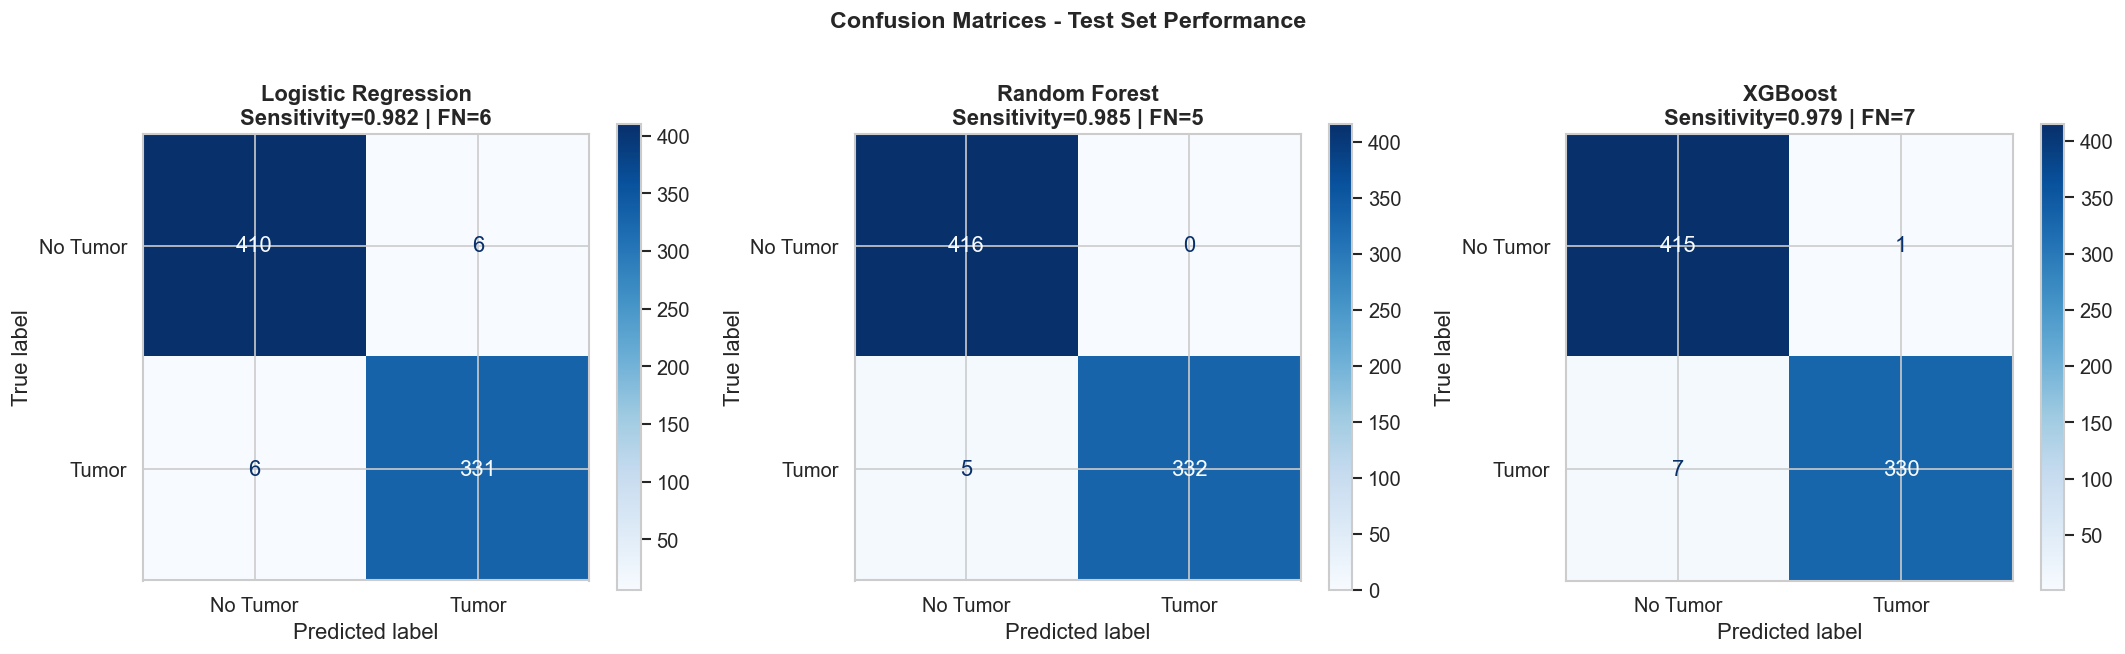


=== Test Set Performance Summary ===
                     Accuracy  Balanced Acc  Precision  Sensitivity  Specificity  F1-Score     MCC  AUC-ROC  AUC-PR  FN (missed tumours)
Model                                                                                                                                   
Logistic Regression    0.9841        0.9839     0.9822       0.9822       0.9856    0.9822  0.9678   0.9991  0.9990                    6
Random Forest          0.9934        0.9926     1.0000       0.9852       1.0000    0.9925  0.9866   0.9990  0.9990                    5
XGBoost                0.9894        0.9884     0.9970       0.9792       0.9976    0.9880  0.9786   0.9983  0.9984                    7


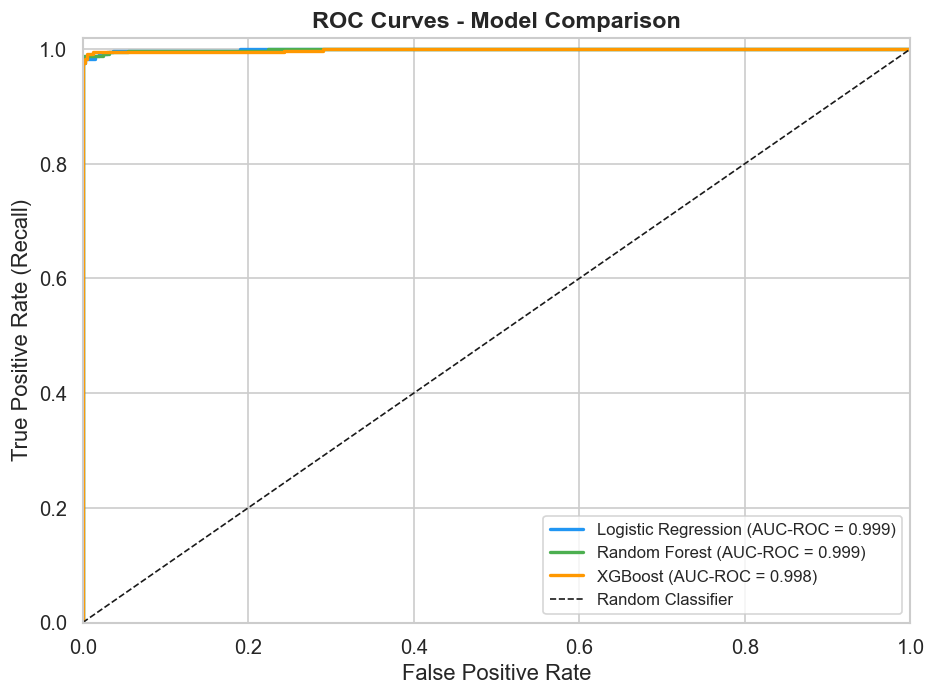

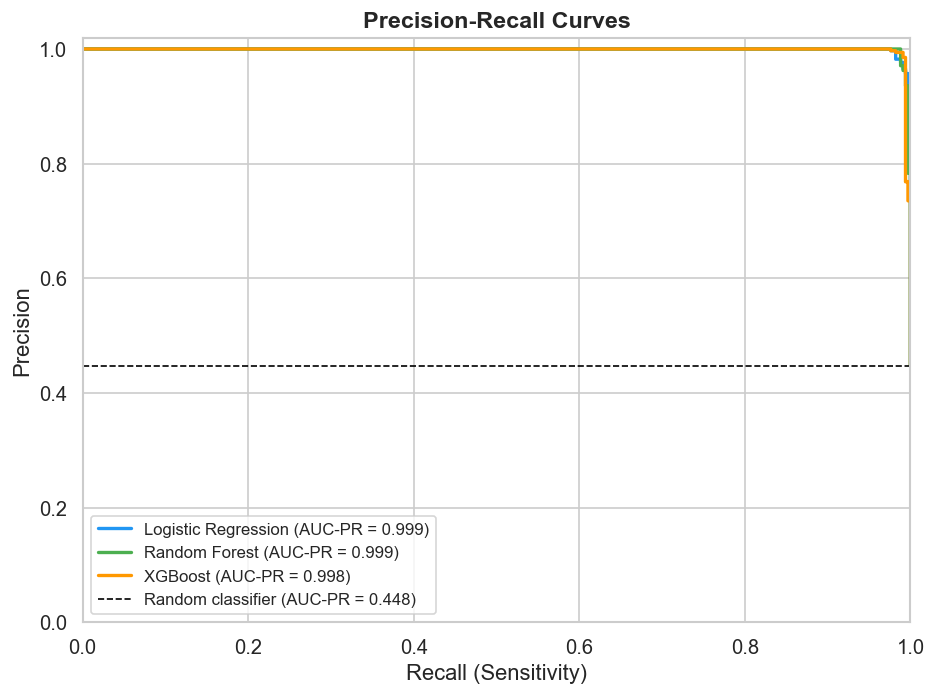


=== Clinical Error Breakdown ===
Model                   Sensitivity  Specificity   FN (missed)   FP (false alarm)
--------------------------------------------------------------------------------
Logistic Regression          0.9822       0.9856             6                  6
Random Forest                0.9852       1.0000             5                  0
XGBoost                      0.9792       0.9976             7                  1

Logistic Regression - Detailed Classification Report
              precision    recall  f1-score   support

    No Tumor       0.99      0.99      0.99       416
       Tumor       0.98      0.98      0.98       337

    accuracy                           0.98       753
   macro avg       0.98      0.98      0.98       753
weighted avg       0.98      0.98      0.98       753


Random Forest - Detailed Classification Report
              precision    recall  f1-score   support

    No Tumor       0.99      1.00      0.99       416
       Tumor       

In [7]:
# 6. TEST SET EVALUATION

test_results = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, grid_search) in enumerate(best_models.items()):
    y_pred = grid_search.predict(X_test)
    y_proba = grid_search.predict_proba(X_test)[:, 1]

    acc      = accuracy_score(y_test, y_pred)
    bal_acc  = balanced_accuracy_score(y_test, y_pred)
    prec     = precision_score(y_test, y_pred)
    rec      = recall_score(y_test, y_pred)          # Sensitivity (tumour class)
    f1       = f1_score(y_test, y_pred)
    mcc      = matthews_corrcoef(y_test, y_pred)
    auc_roc  = roc_auc_score(y_test, y_proba)
    auc_pr   = average_precision_score(y_test, y_proba)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)                     # No-tumour class recall

    test_results.append({
        'Model': name,
        'Accuracy': acc,
        'Balanced Acc': bal_acc,
        'Precision': prec,
        'Sensitivity': rec,
        'Specificity': specificity,
        'F1-Score': f1,
        'MCC': mcc,
        'AUC-ROC': auc_roc,
        'AUC-PR': auc_pr,
        'FN (missed tumours)': fn,
    })

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Tumor', 'Tumor']).plot(ax=axes[idx], cmap='Blues')
    axes[idx].set_title(f'{name}\nSensitivity={rec:.3f} | FN={fn}', fontweight='bold')

plt.suptitle('Confusion Matrices - Test Set Performance', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

results_df = pd.DataFrame(test_results).set_index('Model')
print('\n=== Test Set Performance Summary ===')
print(results_df.round(4).to_string())

# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800']

for (name, grid_search), color in zip(best_models.items(), colors):
    y_proba = grid_search.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_roc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC-ROC = {auc_roc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

# Precision-Recall curves
fig, ax = plt.subplots(figsize=(8, 6))
for (name, grid_search), color in zip(best_models.items(), colors):
    y_proba = grid_search.predict_proba(X_test)[:, 1]
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    ax.plot(rec_curve, prec_curve, label=f'{name} (AUC-PR = {auc_pr:.3f})',
            color=color, linewidth=2)

baseline = y_test.mean()
ax.axhline(baseline, color='black', linestyle='--', linewidth=1,
           label=f'Random classifier (AUC-PR = {baseline:.3f})')
ax.set_xlabel('Recall (Sensitivity)')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('pr_curves.png', bbox_inches='tight')
plt.show()

# Sensitivity / Specificity / FN breakdown
print('\n=== Clinical Error Breakdown ===')
print(f"{'Model':<22} {'Sensitivity':>12} {'Specificity':>12} {'FN (missed)':>13} {'FP (false alarm)':>18}")
print('-' * 80)
for r in test_results:
    tn = confusion_matrix(y_test, best_models[r['Model']].predict(X_test)).ravel()[0]
    fp = confusion_matrix(y_test, best_models[r['Model']].predict(X_test)).ravel()[1]
    fn = r['FN (missed tumours)']
    print(f"{r['Model']:<22} {r['Sensitivity']:>12.4f} {r['Specificity']:>12.4f} {fn:>13d} {fp:>18d}")

# Detailed classification reports
for name, grid_search in best_models.items():
    y_pred = grid_search.predict(X_test)
    print(f'\n{"="*50}')
    print(f'{name} - Detailed Classification Report')
    print(f'{"="*50}')
    print(classification_report(y_test, y_pred, target_names=['No Tumor', 'Tumor']))

## 7. Feature Explainability

- **Logistic Regression:** Coefficient magnitudes
- **Random Forest:** Permutation importance
- **XGBoost:** SHAP values (beeswarm + bar plots)
- **Consensus:** Vote across all 3 models for top-2 features

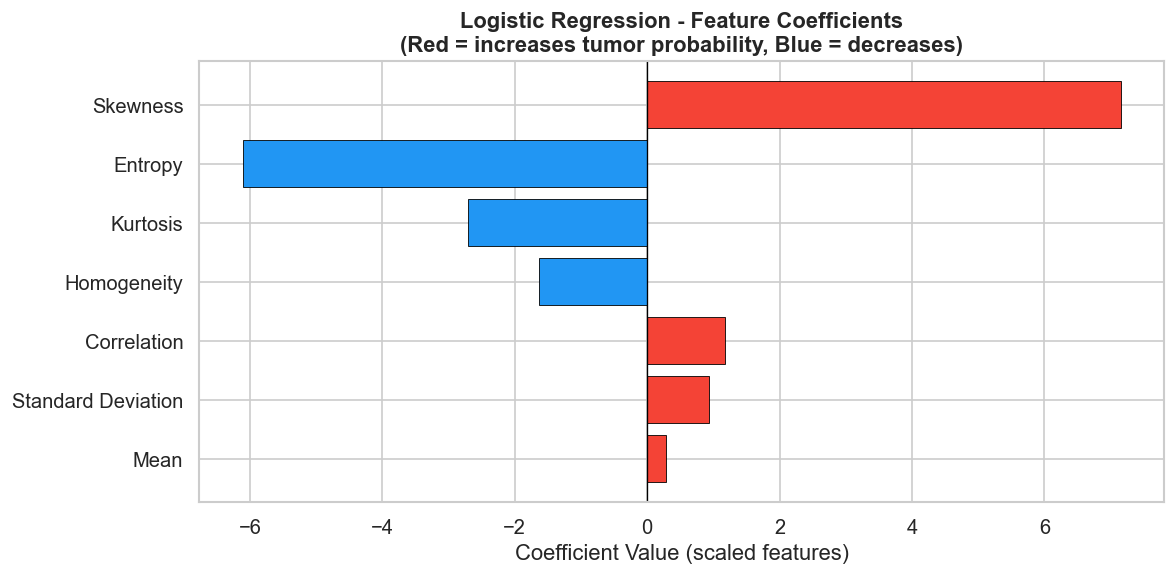


Logistic Regression Feature Importance (by |coefficient|):
           Feature  Coefficient  Abs_Coefficient
          Skewness     7.150103         7.150103
           Entropy    -6.103864         6.103864
          Kurtosis    -2.701111         2.701111
       Homogeneity    -1.640698         1.640698
       Correlation     1.178824         1.178824
Standard Deviation     0.931450         0.931450
              Mean     0.289074         0.289074


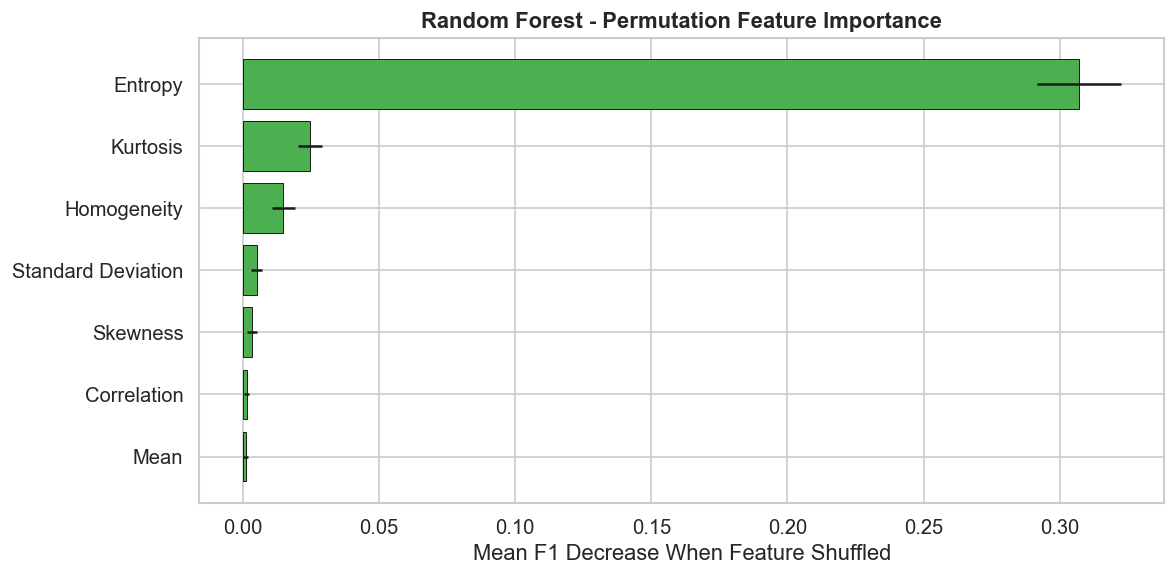


Random Forest Permutation Importance:
           Feature  Importance_Mean  Importance_Std
           Entropy         0.306992        0.015407
          Kurtosis         0.024539        0.004462
       Homogeneity         0.014808        0.004373
Standard Deviation         0.004946        0.002018
          Skewness         0.003384        0.001803
       Correlation         0.001257        0.000879
              Mean         0.000904        0.000920


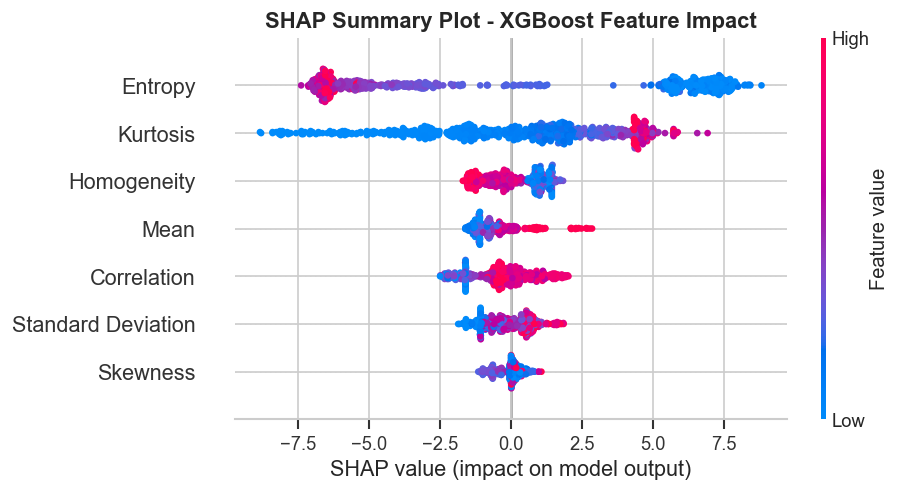

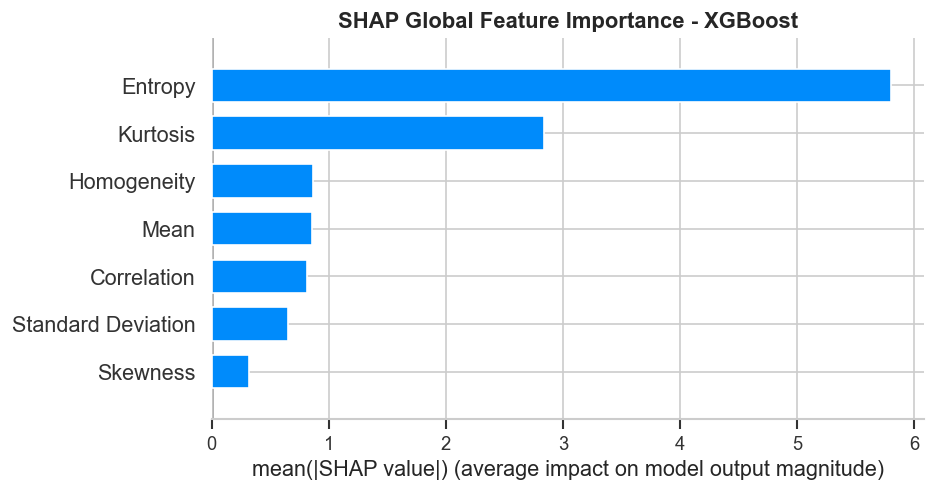


Logistic Regression (by |coefficient|): ['Skewness', 'Entropy']
Random Forest (by permutation importance): ['Entropy', 'Kurtosis']
XGBoost (by mean |SHAP|): ['Entropy', 'Kurtosis']

>>> CONSENSUS TOP 2: ['Entropy', 'Kurtosis']
    (Voted by 3/3 and 2/3 models respectively)


In [8]:
# 7. FEATURE EXPLAINABILITY

# --- 7.1 Logistic Regression Coefficients ---
lr_model = best_models['Logistic Regression'].best_estimator_
lr_coefs = lr_model.named_steps['clf'].coef_[0]

lr_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_coefs,
    'Abs_Coefficient': np.abs(lr_coefs)
}).sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#F44336' if c > 0 else '#2196F3' for c in lr_importance['Coefficient']]
ax.barh(lr_importance['Feature'], lr_importance['Coefficient'], color=bar_colors,
        edgecolor='black', linewidth=0.5)
ax.set_xlabel('Coefficient Value (scaled features)')
ax.set_title('Logistic Regression - Feature Coefficients\n'
             '(Red = increases tumor probability, Blue = decreases)',
             fontweight='bold')
ax.invert_yaxis()
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('lr_coefficients.png', bbox_inches='tight')
plt.show()

print('\nLogistic Regression Feature Importance (by |coefficient|):')
print(lr_importance[['Feature', 'Coefficient', 'Abs_Coefficient']].to_string(index=False))

# --- 7.2 Random Forest Permutation Importance ---
rf_model = best_models['Random Forest'].best_estimator_
X_test_scaled = rf_model.named_steps['scaler'].transform(X_test)

perm_imp = permutation_importance(
    rf_model.named_steps['clf'], X_test_scaled, y_test,
    n_repeats=30, random_state=RANDOM_STATE, scoring='f1'
)

perm_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Mean': perm_imp.importances_mean,
    'Importance_Std': perm_imp.importances_std
}).sort_values('Importance_Mean', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(perm_imp_df['Feature'], perm_imp_df['Importance_Mean'],
        xerr=perm_imp_df['Importance_Std'], color='#4CAF50', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Mean F1 Decrease When Feature Shuffled')
ax.set_title('Random Forest - Permutation Feature Importance', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('rf_permutation_importance.png', bbox_inches='tight')
plt.show()

print('\nRandom Forest Permutation Importance:')
print(perm_imp_df.to_string(index=False))

# --- 7.3 SHAP Values (XGBoost) ---
xgb_model = best_models['XGBoost'].best_estimator_
X_test_scaled_xgb = xgb_model.named_steps['scaler'].transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled_xgb, columns=feature_names)

explainer = shap.TreeExplainer(xgb_model.named_steps['clf'])
shap_values = explainer.shap_values(X_test_scaled_df)

# SHAP Summary (beeswarm)
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled_df, show=False)
plt.title('SHAP Summary Plot - XGBoost Feature Impact', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()

# SHAP Bar Plot
fig, ax = plt.subplots(figsize=(10, 5))
shap.summary_plot(shap_values, X_test_scaled_df, plot_type='bar', show=False)
plt.title('SHAP Global Feature Importance - XGBoost', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight')
plt.show()

# --- 7.4 Consensus Top 2 Features ---

lr_top2 = lr_importance['Feature'].head(2).tolist()
print(f'\nLogistic Regression (by |coefficient|): {lr_top2}')

rf_top2 = perm_imp_df['Feature'].head(2).tolist()
print(f'Random Forest (by permutation importance): {rf_top2}')

shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean_|SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_|SHAP|', ascending=False)
xgb_top2 = shap_importance['Feature'].head(2).tolist()
print(f'XGBoost (by mean |SHAP|): {xgb_top2}')

all_top2 = lr_top2 + rf_top2 + xgb_top2
feature_votes = Counter(all_top2)
consensus_top2 = [f for f, _ in feature_votes.most_common(2)]
print(f'\n>>> CONSENSUS TOP 2: {consensus_top2}')
print(f'    (Voted by {len([m for m in [lr_top2, rf_top2, xgb_top2] if consensus_top2[0] in m])}/3 and '
      f'{len([m for m in [lr_top2, rf_top2, xgb_top2] if consensus_top2[1] in m])}/3 models respectively)')

## 8. Clustering Analysis

- Elbow method + silhouette scores for optimal k
- K-Means (k=2) to match binary classification
- External validation: ARI, NMI, Purity
- PCA visualisation (actual labels vs clusters)
- Hungarian algorithm for optimal label alignment


Evaluating k values:
  k=2: Inertia=19839.1, Silhouette=0.3227
  k=3: Inertia=14786.6, Silhouette=0.3180
  k=4: Inertia=10638.9, Silhouette=0.3312
  k=5: Inertia=9201.6, Silhouette=0.3127
  k=6: Inertia=8043.6, Silhouette=0.2833
  k=7: Inertia=7199.8, Silhouette=0.3015
  k=8: Inertia=6501.9, Silhouette=0.2975
  k=9: Inertia=5952.5, Silhouette=0.3031
  k=10: Inertia=5464.2, Silhouette=0.2947


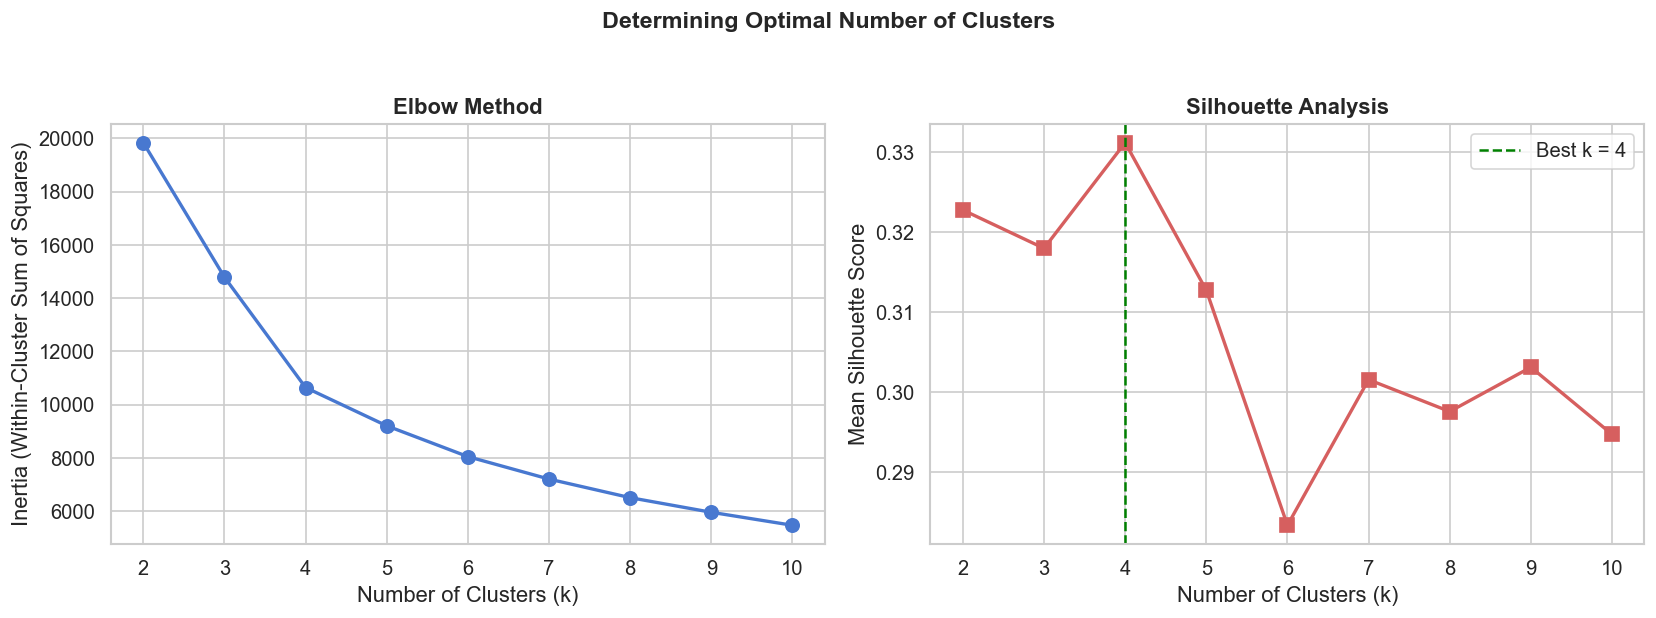

Optimal k by silhouette score: 4

=== Contingency Table: Actual Class vs K-Means Cluster ===
Cluster          0     1   All
Actual Class                  
0             2073     6  2079
1              251  1432  1683
All           2324  1438  3762

=== Cluster Quality Metrics ===
Adjusted Rand Index (ARI):           0.7452  (1 = perfect, 0 = random)
Normalized Mutual Information (NMI):  0.6887  (1 = perfect, 0 = independent)
Cluster Purity:                       0.9317  (1 = pure clusters)
Silhouette Score:                     0.3227


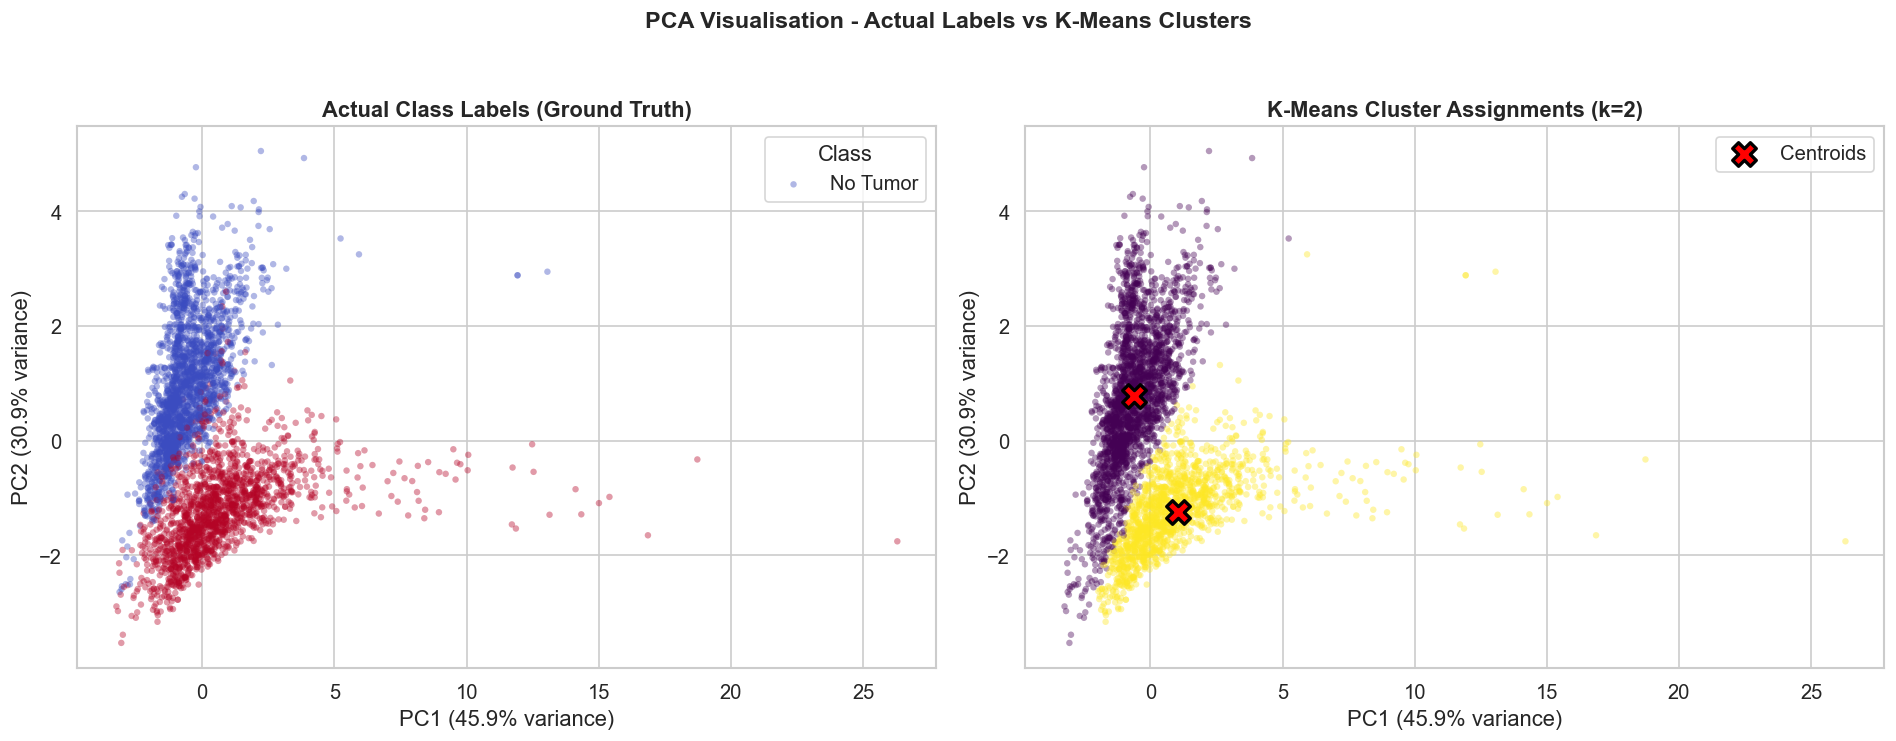

Total PCA variance explained: 76.8%


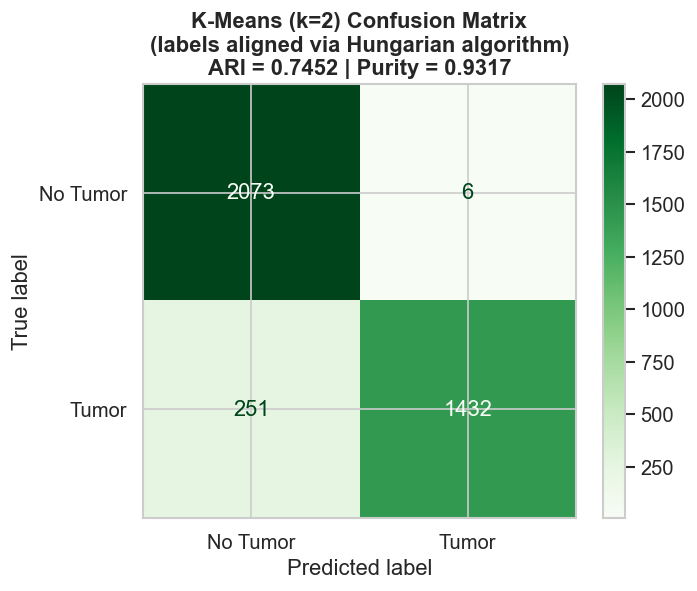


Clustering as Classification (after label alignment):
              precision    recall  f1-score   support

    No Tumor       0.89      1.00      0.94      2079
       Tumor       1.00      0.85      0.92      1683

    accuracy                           0.93      3762
   macro avg       0.94      0.92      0.93      3762
weighted avg       0.94      0.93      0.93      3762



In [9]:
# 8. CLUSTERING ANALYSIS

# Scale features for clustering
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(X_clean)

# --- 8.1 Elbow Method + Silhouette Score ---
k_range = range(2, 11)
inertias = []
silhouette_scores_list = []

print('\nEvaluating k values:')
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_cluster, labels)
    silhouette_scores_list.append(sil)
    print(f'  k={k}: Inertia={km.inertia_:.1f}, Silhouette={sil:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xticks(list(k_range))

axes[1].plot(k_range, silhouette_scores_list, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_title('Silhouette Analysis', fontweight='bold')
axes[1].set_xticks(list(k_range))

best_k_silhouette = list(k_range)[np.argmax(silhouette_scores_list)]
axes[1].axvline(x=best_k_silhouette, color='green', linestyle='--', linewidth=1.5,
                label=f'Best k = {best_k_silhouette}')
axes[1].legend()

plt.suptitle('Determining Optimal Number of Clusters', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('elbow_silhouette.png', bbox_inches='tight')
plt.show()
print(f'Optimal k by silhouette score: {best_k_silhouette}')

# --- 8.2 K-Means with k=2 ---
km_final = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)
cluster_labels = km_final.fit_predict(X_cluster)

# Contingency table
contingency = pd.crosstab(
    pd.Series(y.values, name='Actual Class'),
    pd.Series(cluster_labels, name='Cluster'),
    margins=True
)
print('\n=== Contingency Table: Actual Class vs K-Means Cluster ===')
print(contingency)

# Cluster quality metrics
ari = adjusted_rand_score(y, cluster_labels)
nmi = normalized_mutual_info_score(y, cluster_labels)
contingency_no_margin = pd.crosstab(y, cluster_labels)
purity = contingency_no_margin.max(axis=0).sum() / len(y)
sil_final = silhouette_score(X_cluster, cluster_labels)

print(f'\n=== Cluster Quality Metrics ===')
print(f'Adjusted Rand Index (ARI):           {ari:.4f}  (1 = perfect, 0 = random)')
print(f'Normalized Mutual Information (NMI):  {nmi:.4f}  (1 = perfect, 0 = independent)')
print(f'Cluster Purity:                       {purity:.4f}  (1 = pure clusters)')
print(f'Silhouette Score:                     {sil_final:.4f}')

# --- 8.3 PCA Visualisation ---
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y.values, cmap='coolwarm',
                           alpha=0.4, s=15, edgecolors='none')
axes[0].set_title('Actual Class Labels (Ground Truth)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend(*scatter1.legend_elements(), title='Class', labels=['No Tumor', 'Tumor'])

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis',
                           alpha=0.4, s=15, edgecolors='none')
centres_pca = pca.transform(km_final.cluster_centers_)
axes[1].scatter(centres_pca[:, 0], centres_pca[:, 1], c='red', marker='X',
                s=200, edgecolors='black', linewidth=2, zorder=5, label='Centroids')
axes[1].set_title('K-Means Cluster Assignments (k=2)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].legend(loc='upper right')

plt.suptitle('PCA Visualisation - Actual Labels vs K-Means Clusters',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('pca_clusters_vs_actual.png', bbox_inches='tight')
plt.show()
print(f'Total PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

# --- 8.4 Aligned Confusion Matrix ---
contingency_matrix = pd.crosstab(y, cluster_labels).values
row_ind, col_ind = linear_sum_assignment(-contingency_matrix)
label_mapping = {col_ind[i]: row_ind[i] for i in range(len(col_ind))}
cluster_labels_mapped = np.array([label_mapping[c] for c in cluster_labels])

cm_cluster = confusion_matrix(y, cluster_labels_mapped)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_cluster, display_labels=['No Tumor', 'Tumor']).plot(ax=ax, cmap='Greens')
ax.set_title(f'K-Means (k=2) Confusion Matrix\n(labels aligned via Hungarian algorithm)\n'
             f'ARI = {ari:.4f} | Purity = {purity:.4f}', fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_confusion_matrix.png', bbox_inches='tight')
plt.show()

print('\nClustering as Classification (after label alignment):')
print(classification_report(y, cluster_labels_mapped, target_names=['No Tumor', 'Tumor']))

## 9. Summary & Conclusions

In [10]:
# 9. FINAL SUMMARY

print('\n--- Dataset ---')
print(f'Samples: {len(df)}')
print(f'Original features: {X.shape[1]} (12)')
print(f'Features after removal: {X_clean.shape[1]}')
print(f'Features dropped: {features_to_drop}')
print(f'Justification: Mathematical redundancy (Variance=StdDev^2, ASM=Energy^2) & high correlation')

print('\n--- Classification Results (Test Set) ---')
print(results_df.round(4).to_string())

best_model_name = results_df['F1-Score'].idxmax()
best_f1 = results_df.loc[best_model_name, 'F1-Score']
best_auc = results_df.loc[best_model_name, 'AUC-ROC']
print(f'\nBest model: {best_model_name} (F1={best_f1:.4f}, AUC-ROC={best_auc:.4f})')

print(f'\n--- Top 2 Features (Consensus) ---')
print(f'{consensus_top2}')

print(f'\n--- Clustering (K-Means, k=2) ---')
print(f'Adjusted Rand Index:           {ari:.4f}')
print(f'Normalized Mutual Information:  {nmi:.4f}')
print(f'Cluster Purity:                 {purity:.4f}')

if ari > 0.5:
    print('\n>>> Strong cluster-class alignment: the textural/statistical features')
    print('    naturally separate tumor from non-tumor MRI scans.')
elif ari > 0.2:
    print('\n>>> Moderate cluster-class alignment: features partially capture the')
    print('    tumor/non-tumor distinction, but supervised learning is needed.')
else:
    print('\n>>> Weak cluster-class alignment: the unsupervised structure does not')
    print('    strongly correspond to tumor presence. This highlights the value')
    print('    of supervised learning for this classification task.')

print('\n--- Generated Plots ---')
import glob
plots = sorted(glob.glob('*.png'))
for p in plots:
    print(f'  {p}')


--- Dataset ---
Samples: 3762
Original features: 12 (12)
Features after removal: 7
Features dropped: ['Variance', 'ASM', 'Energy', 'Contrast', 'Dissimilarity']
Justification: Mathematical redundancy (Variance=StdDev^2, ASM=Energy^2) & high correlation

--- Classification Results (Test Set) ---
                     Accuracy  Balanced Acc  Precision  Sensitivity  Specificity  F1-Score     MCC  AUC-ROC  AUC-PR  FN (missed tumours)
Model                                                                                                                                   
Logistic Regression    0.9841        0.9839     0.9822       0.9822       0.9856    0.9822  0.9678   0.9991  0.9990                    6
Random Forest          0.9934        0.9926     1.0000       0.9852       1.0000    0.9925  0.9866   0.9990  0.9990                    5
XGBoost                0.9894        0.9884     0.9970       0.9792       0.9976    0.9880  0.9786   0.9983  0.9984                    7

Best model: Random